In [1]:
from spikingjelly.datasets.n_mnist import NMNIST
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:
train_ds = NMNIST('../data/', data_type='frame', train=True, frames_number=10, split_by='time')
test_ds = NMNIST('../data/', data_type='frame', train=False, frames_number=10, split_by='time')

The directory [../data/frames_number_10_split_by_time] already exists.
The directory [../data/frames_number_10_split_by_time] already exists.


In [11]:
img, label = train_ds[0]
print(label)

0


In [17]:


def randomly_permute_image_values(img):
    """
    Given an image tensor of shape (C, H, W), this function randomly permutes the pixel values
    in each channel independently.
    """
    flattened_img = img.view(img.size(0), -1)  
    channel_dim, all_pixels = flattened_img.size()
    perm_indices = torch.rand(channel_dim, all_pixels).argsort(dim=1)
    permuted_flattened_img = torch.gather(flattened_img, 1, perm_indices)
    permuted_img = permuted_flattened_img.view_as(img)
    return permuted_img  

In [25]:
img_tensor = torch.from_numpy(img[0]).float()
shuffled_tensor = randomly_permute_image_values(img_tensor)

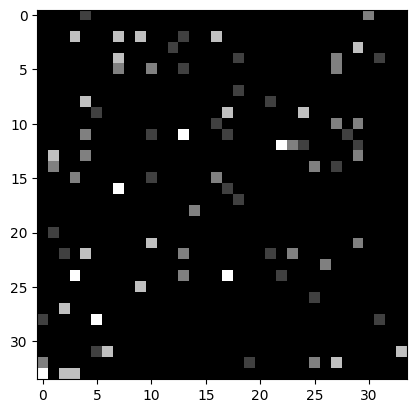

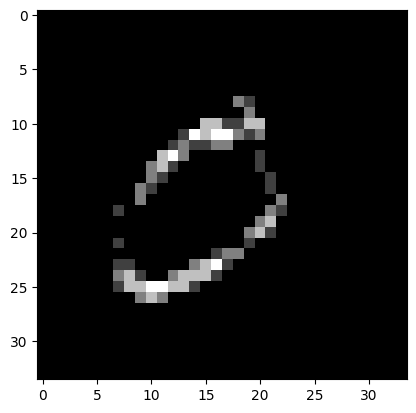

In [27]:




from matplotlib import pyplot as plt
plt.imshow(shuffled_tensor[0, :, :], cmap='gray')
plt.show()
plt.imshow(img_tensor[0, :, :], cmap='gray')
plt.show()

In [26]:
data_loader = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=4)
sum_on, sum_off = 0.0, 0.0
total_pixels_per_channel = 0

print("--- Pass 1: Calculating Mean ---")
# Use torch.no_grad() to save memory and computation
with torch.no_grad():
    for data, _ in tqdm(data_loader):
        # data shape is (B, T, C, H, W) where C=2
        # Summing pixel values for each channel across the batch
        sum_on += data[:, :, 0, :, :].sum()
        sum_off += data[:, :, 1, :, :].sum()
        
        # Count the total number of pixels for one channel
        # data.numel() gives total elements in the batch tensor
        # We divide by 2 because there are two channels
        total_pixels_per_channel += data.numel() / 2

mean_on = sum_on / total_pixels_per_channel
mean_off = sum_off / total_pixels_per_channel

print(f"\nMean (ON channel): {mean_on:.6f}")
print(f"Mean (OFF channel): {mean_off:.6f}")


#
# PASS 2: Calculate the standard deviation
# ---------------------------------------------
sum_sq_diff_on, sum_sq_diff_off = 0.0, 0.0

print("\n--- Pass 2: Calculating Standard Deviation ---")
with torch.no_grad():
    for data, _ in tqdm(data_loader):
        # data shape is (B, T, C, H, W)
        # Calculate sum of squared differences from the mean
        sum_sq_diff_on += ((data[:, :, 0, :, :] - mean_on) ** 2).sum()
        sum_sq_diff_off += ((data[:, :, 1, :, :] - mean_off) ** 2).sum()

std_on = torch.sqrt(sum_sq_diff_on / total_pixels_per_channel)
std_off = torch.sqrt(sum_sq_diff_off / total_pixels_per_channel)

print(f"\nStd Dev (ON channel): {std_on:.6f}")
print(f"Std Dev (OFF channel): {std_off:.6f}")


--- Pass 1: Calculating Mean ---


100%|██████████| 938/938 [00:17<00:00, 52.97it/s]



Mean (ON channel): 0.180647
Mean (OFF channel): 0.180247

--- Pass 2: Calculating Standard Deviation ---


100%|██████████| 938/938 [00:32<00:00, 29.19it/s]


Std Dev (ON channel): 0.753486
Std Dev (OFF channel): 0.696370


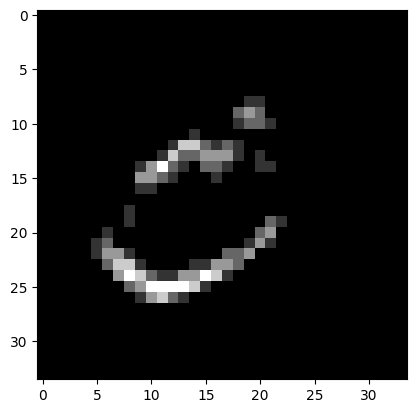

In [19]:
from matplotlib import pyplot as plt
plt.imshow(train_ds[1][0][0][0][::].squeeze(), cmap='gray')